# EDA-09: Order Fulfilment & SLA | Return Analysis | Inventory Health

**Sections 3.1, 3.2, 3.3**

In [1]:

import sys, io
if hasattr(sys.stdout, 'buffer'):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import warnings; warnings.filterwarnings('ignore')

orders  = pd.read_csv('orders.csv',      parse_dates=['order_date'])
ship    = pd.read_csv('shipments.csv',   parse_dates=['ship_date','delivery_date'])
geo     = pd.read_csv('geography.csv')
inv     = pd.read_csv('inventory.csv',   parse_dates=['snapshot_date'])
rets    = pd.read_csv('returns.csv',     parse_dates=['return_date'])
prods   = pd.read_csv('products.csv')
items   = pd.read_csv('order_items.csv', low_memory=False)
pays    = pd.read_csv('payments.csv')

# Join shipments -> orders -> geography
ship_full = ship.merge(orders[['order_id','order_date','zip','order_status']], on='order_id', how='left')
ship_full = ship_full.merge(geo[['zip','region']], on='zip', how='left')
ship_full['fulfil_days'] = (ship_full['delivery_date'] - ship_full['order_date']).dt.days
ship_full['time_to_ship'] = (ship_full['ship_date']    - ship_full['order_date']).dt.days
ship_full['order_year']   = ship_full['order_date'].dt.year

# Product revenue / cost helper
items_p = items.merge(prods[['product_id','category','cogs']], on='product_id', how='left')
items_p['rev_line']  = items_p['quantity'] * items_p['unit_price']
items_p['cogs_line'] = items_p['quantity'] * items_p['cogs']

# Capped refund (min of refund vs payment)
rets_p = rets.merge(pays[['order_id','payment_value']], on='order_id', how='left')
rets_p['refund_capped'] = rets_p[['refund_amount','payment_value']].min(axis=1)

print('Data loaded successfully.')
print(f"  orders     : {len(orders):,}")
print(f"  shipments  : {len(ship):,}")
print(f"  returns    : {len(rets):,}")
print(f"  inventory  : {len(inv):,}")


Data loaded successfully.
  orders     : 646,945
  shipments  : 566,067
  returns    : 39,939
  inventory  : 60,247


---
## 3.1  Order Fulfilment & SLA
### 3.1a  Cancellation & order status mix

In [2]:

# ── 3.1a Cancellation & status mix ──────────────────────────────────────────
total_orders = len(orders)
status_ct    = orders['order_status'].value_counts()
status_pct   = status_ct / total_orders * 100

print('=== ORDER STATUS MIX ===')
for s, n in status_ct.items():
    print(f'  {s:12s}: {n:7,}  ({n/total_orders*100:5.1f}%)')
print()

cancel_rate = status_pct.get('cancelled', 0)
return_rate = status_pct.get('returned',  0)
print(f'Cancellation rate : {cancel_rate:.2f}%')
print(f'Post-ship return  : {return_rate:.2f}%')
print(f'Loss rate total   : {cancel_rate + return_rate:.2f}%')


=== ORDER STATUS MIX ===
  delivered   : 516,716  ( 79.9%)
  cancelled   :  59,462  (  9.2%)
  returned    :  36,142  (  5.6%)
  shipped     :  13,773  (  2.1%)
  paid        :  13,577  (  2.1%)
  created     :   7,275  (  1.1%)

Cancellation rate : 9.19%
Post-ship return  : 5.59%
Loss rate total   : 14.78%


### 3.1b  Fulfilment time distribution & SLA breach

In [3]:

# ── 3.1b Fulfilment time distribution & SLA breach ──────────────────────────
SLA_DAYS = 7          # business SLA threshold

print(f'=== FULFILMENT TIME DISTRIBUTION (SLA = {SLA_DAYS}d) ===')
print(ship_full['fulfil_days'].describe().round(2).to_string())
print()

sla_breach = (ship_full['fulfil_days'] > SLA_DAYS).mean() * 100
print(f'Overall SLA breach rate (>{SLA_DAYS}d) : {sla_breach:.1f}%')
print()

# Distribution buckets
bins   = [0,3,5,7,10]
labels = ['<=3d','4-5d','6-7d','8-10d']
ship_full['fd_bucket'] = pd.cut(ship_full['fulfil_days'], bins=bins, labels=labels)
bucket_ct  = ship_full['fd_bucket'].value_counts().sort_index()
bucket_pct = bucket_ct / len(ship_full) * 100
print('Fulfilment-day bucket breakdown:')
for b, pct in bucket_pct.items():
    print(f'  {b} : {pct:5.1f}%  (n={bucket_ct[b]:,})')
print()
print('Time-to-ship (order→dispatch) stats:')
print(ship_full['time_to_ship'].describe().round(2).to_string())


=== FULFILMENT TIME DISTRIBUTION (SLA = 7d) ===
count    566067.00
mean          6.00
std           2.04
min           2.00
25%           4.00
50%           6.00
75%           7.00
max          10.00

Overall SLA breach rate (>7d) : 24.9%

Fulfilment-day bucket breakdown:
  <=3d :  12.5%  (n=70,777)
  4-5d :  29.2%  (n=165,370)
  6-7d :  33.4%  (n=188,870)
  8-10d :  24.9%  (n=141,050)

Time-to-ship (order→dispatch) stats:
count    566067.00
mean          1.50
std           1.12
min           0.00
25%           0.00
50%           1.00
75%           2.00
max           3.00


### 3.1c  Regional SLA breakdown (geographic bottleneck)

In [4]:

# ── 3.1c Regional SLA breakdown ─────────────────────────────────────────────
SLA_DAYS = 7

region_sla = ship_full.groupby('region').agg(
    n_shipments   = ('order_id',    'count'),
    avg_fulfil    = ('fulfil_days', 'mean'),
    median_fulfil = ('fulfil_days', 'median'),
    p90_fulfil    = ('fulfil_days', lambda x: x.quantile(0.9)),
    sla_breach_pct= ('fulfil_days', lambda x: (x > SLA_DAYS).mean() * 100),
    avg_tts       = ('time_to_ship','mean'),
).reset_index().sort_values('sla_breach_pct', ascending=False)

pd.set_option('display.float_format','{:.2f}'.format,'display.width',160)
print('=== REGIONAL FULFILMENT METRICS ===')
print(region_sla.to_string(index=False))
print()

# Cancellation by region
ord_geo = orders.merge(geo[['zip','region']], on='zip', how='left')
cancel_region = (ord_geo.groupby('region')
                 .apply(lambda x: (x['order_status']=='cancelled').mean() * 100)
                 .rename('cancel_pct').reset_index())
print('Cancellation rate by region:')
print(cancel_region.to_string(index=False))


=== REGIONAL FULFILMENT METRICS ===
 region  n_shipments  avg_fulfil  median_fulfil  p90_fulfil  sla_breach_pct  avg_tts
   West       146923        6.00           6.00        9.00           24.98     1.50
   East       257756        6.00           6.00        9.00           24.93     1.50
Central       161388        6.00           6.00        9.00           24.85     1.50



Cancellation rate by region:
 region  cancel_pct
Central        9.26
   East        9.20
   West        9.09


### 3.1d  Fulfilment trend by year

In [5]:

# ── 3.1d Fulfilment trend by year ────────────────────────────────────────────
ful_yr = ship_full.groupby('order_year').agg(
    n_ship     = ('order_id',    'count'),
    avg_fd     = ('fulfil_days', 'mean'),
    sla_breach = ('fulfil_days', lambda x: (x>7).mean()*100),
    avg_tts    = ('time_to_ship','mean'),
).reset_index()
print('=== FULFILMENT TREND by YEAR ===')
print(ful_yr.to_string(index=False))


=== FULFILMENT TREND by YEAR ===
 order_year  n_ship  avg_fd  sla_breach  avg_tts
       2012   28146    6.01       25.11     1.50
       2013   67390    6.00       25.01     1.49
       2014   70844    5.98       24.72     1.50
       2015   72456    6.00       24.85     1.50
       2016   72390    6.00       25.00     1.50
       2017   66943    6.00       24.76     1.50
       2018   60966    6.00       25.14     1.50
       2019   36431    5.99       24.99     1.49
       2020   30595    6.00       24.69     1.50
       2021   29695    6.00       24.96     1.49
       2022   30211    6.00       24.94     1.49


### 3.1e  Chart — regional SLA comparison

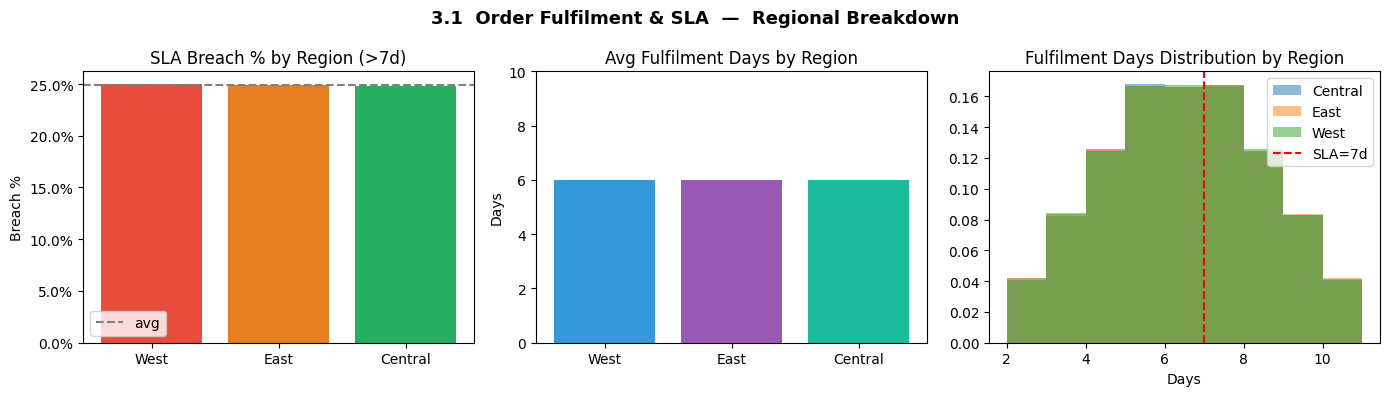

fig_eda09_31_sla.png saved.


In [6]:

# ── 3.1e Chart — regional SLA comparison ─────────────────────────────────────
SLA_DAYS = 7
region_sla = ship_full.groupby('region').agg(
    n_shipments   = ('order_id',    'count'),
    avg_fulfil    = ('fulfil_days', 'mean'),
    sla_breach_pct= ('fulfil_days', lambda x: (x > SLA_DAYS).mean() * 100),
    avg_tts       = ('time_to_ship','mean'),
).reset_index().sort_values('sla_breach_pct', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) SLA breach % by region
ax = axes[0]
clrs = ['#e74c3c','#e67e22','#27ae60']
ax.bar(region_sla['region'], region_sla['sla_breach_pct'], color=clrs)
ax.axhline(region_sla['sla_breach_pct'].mean(), ls='--', color='gray', label='avg')
ax.set_title('SLA Breach % by Region (>7d)')
ax.set_ylabel('Breach %')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()

# (b) Avg fulfilment days by region
ax = axes[1]
ax.bar(region_sla['region'], region_sla['avg_fulfil'], color=['#3498db','#9b59b6','#1abc9c'])
ax.set_title('Avg Fulfilment Days by Region')
ax.set_ylabel('Days')
ax.set_ylim(0, 10)

# (c) Fulfilment-days distribution
ax = axes[2]
for reg, grp in ship_full.groupby('region'):
    ax.hist(grp['fulfil_days'], bins=range(2,12), alpha=0.5, label=reg, density=True)
ax.axvline(SLA_DAYS, color='red', ls='--', label=f'SLA={SLA_DAYS}d')
ax.set_title('Fulfilment Days Distribution by Region')
ax.set_xlabel('Days')
ax.legend()

plt.suptitle('3.1  Order Fulfilment & SLA  —  Regional Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda09_31_sla.png', dpi=130, bbox_inches='tight')
plt.show()
print('fig_eda09_31_sla.png saved.')


---
## 3.2  Return Analysis
### 3.2a  Return rate by category & reason

In [7]:

# ── 3.2a Return rate by category ─────────────────────────────────────────────
items_cat = items.merge(prods[['product_id','category']], on='product_id', how='left')
rets_cat  = rets.merge(prods[['product_id','category']], on='product_id', how='left')

cat_ord   = items_cat.groupby('category')['order_id'].nunique().rename('n_orders')
cat_ret   = rets_cat.groupby('category')['return_id'].count().rename('n_returns')
cat_qty   = rets_cat.groupby('category')['return_quantity'].sum().rename('ret_units')
cat_ref   = rets_cat.groupby('category')['refund_amount'].sum().rename('gross_refund')

cat_df = pd.concat([cat_ord, cat_ret, cat_qty, cat_ref], axis=1).reset_index()
cat_df['ret_rate_pct'] = cat_df['n_returns'] / cat_df['n_orders'] * 100

pd.set_option('display.float_format','{:,.0f}'.format)
print('=== RETURN RATE BY CATEGORY ===')
print(cat_df.to_string(index=False))
print()

# Most common return reasons (all)
print('=== TOP RETURN REASONS (overall) ===')
reason_ct = rets['return_reason'].value_counts()
for r, n in reason_ct.items():
    print(f'  {r:20s}: {n:6,}  ({n/len(rets)*100:.1f}%)')
print()

# Reason by category
print('=== RETURN REASON MIX BY CATEGORY (%) ===')
rc = rets_cat.groupby(['category','return_reason'])['return_id'].count().unstack(fill_value=0)
rc_pct = rc.div(rc.sum(axis=1), axis=0) * 100
pd.set_option('display.float_format','{:.1f}'.format)
print(rc_pct.to_string())


=== RETURN RATE BY CATEGORY ===
  category  n_orders  n_returns  ret_units  gross_refund  ret_rate_pct
    Casual     23600       1294       3499    14,027,094             5
      GenZ     37054       2126       5869    11,145,648             6
   Outdoor    200454      14720      40417    78,717,515             7
Streetwear    389543      21799      59801   406,708,249             6

=== TOP RETURN REASONS (overall) ===
  wrong_size          : 13,967  (35.0%)
  defective           :  8,020  (20.1%)
  not_as_described    :  7,035  (17.6%)
  changed_mind        :  6,931  (17.4%)
  late_delivery       :  3,986  (10.0%)

=== RETURN REASON MIX BY CATEGORY (%) ===
return_reason  changed_mind  defective  late_delivery  not_as_described  wrong_size
category                                                                           
Casual                 17.6       20.2            9.4              17.7        35.1
GenZ                   16.4       20.2           11.3              17.6        3

### 3.2b  Net revenue erosion waterfall

In [8]:

# ── 3.2b Net revenue erosion from returns & discounts ─────────────────────────
gross_rev   = (items_p['rev_line']).sum()
total_cogs  = (items_p['cogs_line']).sum()
total_disc  = items['discount_amount'].sum()
gross_refund= rets['refund_amount'].sum()
# Capped refund
rets_pay    = rets.merge(pays[['order_id','payment_value']], on='order_id', how='left')
rets_pay['refund_capped'] = rets_pay[['refund_amount','payment_value']].min(axis=1)
total_refund_capped = rets_pay['refund_capped'].sum()

net_rev     = gross_rev - total_disc - total_refund_capped
gross_margin= gross_rev - total_cogs
gm_pct      = gross_margin / net_rev * 100
npm_pct     = (net_rev - total_cogs) / net_rev * 100

fmt = lambda x: f'{x/1e9:,.1f}B'
print('=== NET REVENUE EROSION WATERFALL ===')
print(f'  Gross Revenue           : {fmt(gross_rev)}')
print(f'  – Discounts             : {fmt(total_disc)}  ({total_disc/gross_rev*100:.1f}%)')
print(f'  – Refunds (capped)      : {fmt(total_refund_capped)}  ({total_refund_capped/gross_rev*100:.1f}%)')
print(f'  = Net Revenue           : {fmt(net_rev)}')
print(f'  – COGS                  : {fmt(total_cogs)}')
print(f'  = Gross Profit          : {fmt(gross_margin)}')
print()
print(f'  Gross Margin %          : {gm_pct:.2f}%')
print(f'  Net Profit Margin %     : {npm_pct:.2f}%')
print()
print(f'  Uncapped refund total   : {fmt(gross_refund)}')
print(f'  Overpay shielded        : {fmt(gross_refund-total_refund_capped)}')

# Trend: return value erosion by year
rets_yr = rets_pay.merge(orders[['order_id','order_date']], on='order_id', how='left')
rets_yr['year'] = pd.to_datetime(rets_yr['order_date']).dt.year
yr_erosion = rets_yr.groupby('year').agg(
    n_returns       = ('return_id','count'),
    refund_capped   = ('refund_capped','sum'),
    gross_refund    = ('refund_amount','sum'),
).reset_index()
yr_rev = items_p.merge(orders[['order_id','order_date']], on='order_id', how='left')
yr_rev['year'] = yr_rev['order_date'].dt.year
yr_gross = yr_rev.groupby('year')['rev_line'].sum().rename('gross_rev')
yr_erosion = yr_erosion.merge(yr_gross, on='year')
yr_erosion['erosion_pct'] = yr_erosion['refund_capped'] / yr_erosion['gross_rev'] * 100

pd.set_option('display.float_format','{:,.2f}'.format,'display.width',160)
print()
print('=== REFUND EROSION BY YEAR ===')
print(yr_erosion.to_string(index=False))


=== NET REVENUE EROSION WATERFALL ===


  Gross Revenue           : 16.4B
  – Discounts             : 0.7B  (4.6%)
  – Refunds (capped)      : 0.5B  (3.1%)
  = Net Revenue           : 15.2B
  – COGS                  : 14.2B
  = Gross Profit          : 2.3B

  Gross Margin %          : 14.94%
  Net Profit Margin %     : 6.66%

  Uncapped refund total   : 0.5B
  Overpay shielded        : 0.0B

=== REFUND EROSION BY YEAR ===
 year  n_returns  refund_capped  gross_refund        gross_rev  erosion_pct
 2012       2115  23,609,396.67 23,609,396.67   741,497,748.02         3.18
 2013       4944  51,516,316.94 51,996,488.43 1,657,169,417.27         3.11
 2014       5105  57,772,645.19 58,245,013.52 1,871,845,882.80         3.09
 2015       5168  60,002,065.55 60,567,497.04 1,889,933,826.92         3.17
 2016       5153  65,818,272.16 66,336,938.53 2,104,640,677.54         3.13
 2017       4698  58,453,814.35 59,012,186.53 1,911,164,325.28         3.06
 2018       4122  55,753,893.17 56,219,259.06 1,850,122,456.08         3.01
 2019

### 3.2c  Chart — return analysis overview

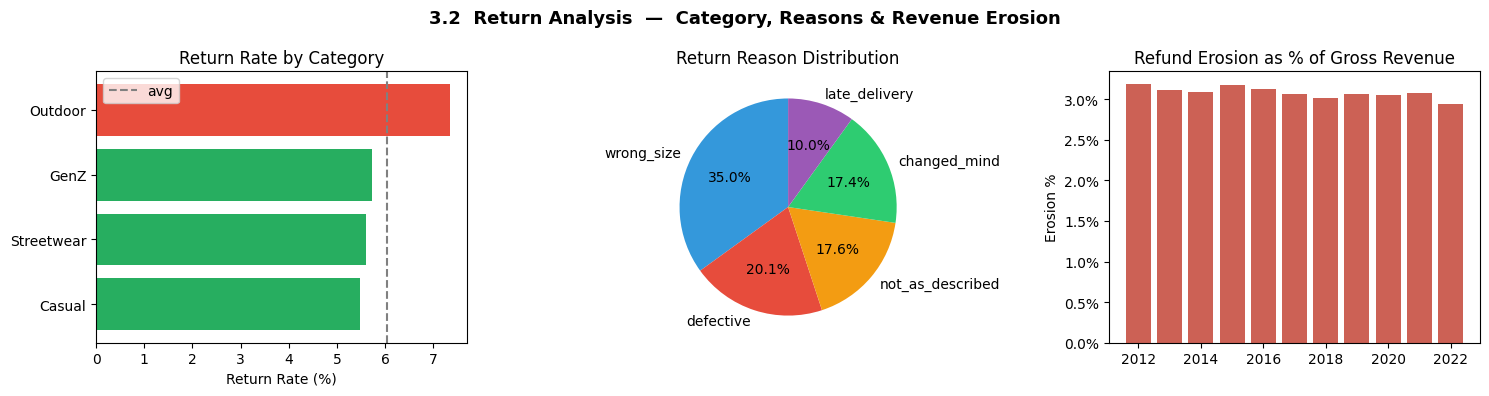

fig_eda09_32_returns.png saved.


In [9]:

# ── 3.2c Return analysis chart ───────────────────────────────────────────────
items_cat = items.merge(prods[['product_id','category']], on='product_id', how='left')
rets_cat  = rets.merge(prods[['product_id','category']], on='product_id', how='left')
cat_ord   = items_cat.groupby('category')['order_id'].nunique().rename('n_orders')
cat_ret   = rets_cat.groupby('category')['return_id'].count().rename('n_returns')
cat_df    = pd.concat([cat_ord, cat_ret], axis=1).reset_index()
cat_df['ret_rate_pct'] = cat_df['n_returns'] / cat_df['n_orders'] * 100

reason_ct = rets['return_reason'].value_counts()

rets_pay2 = rets.merge(pays[['order_id','payment_value']], on='order_id', how='left')
rets_pay2['refund_capped'] = rets_pay2[['refund_amount','payment_value']].min(axis=1)
rets_yr2  = rets_pay2.merge(orders[['order_id','order_date']], on='order_id', how='left')
rets_yr2['year'] = pd.to_datetime(rets_yr2['order_date']).dt.year
items_p2  = items.merge(prods[['product_id','cogs']], on='product_id', how='left')
items_p2['rev_line'] = items_p2['quantity'] * items_p2['unit_price']
yr_rev2   = items_p2.merge(orders[['order_id','order_date']], on='order_id', how='left')
yr_rev2['year'] = yr_rev2['order_date'].dt.year
yr_gross2 = yr_rev2.groupby('year')['rev_line'].sum().rename('gross_rev')
yr_er2    = rets_yr2.groupby('year').agg(refund_capped=('refund_capped','sum')).reset_index()
yr_er2    = yr_er2.merge(yr_gross2, on='year')
yr_er2['erosion_pct'] = yr_er2['refund_capped'] / yr_er2['gross_rev'] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Return rate by category
ax = axes[0]
cat_sorted = cat_df.sort_values('ret_rate_pct', ascending=True)
colors_cat = ['#27ae60' if r < 6 else '#e74c3c' for r in cat_sorted['ret_rate_pct']]
ax.barh(cat_sorted['category'], cat_sorted['ret_rate_pct'], color=colors_cat)
ax.axvline(cat_df['ret_rate_pct'].mean(), ls='--', color='gray', label='avg')
ax.set_title('Return Rate by Category')
ax.set_xlabel('Return Rate (%)')
ax.legend()

# (b) Top return reasons (pie)
ax = axes[1]
ax.pie(reason_ct.values, labels=reason_ct.index, autopct='%1.1f%%', startangle=90,
       colors=['#3498db','#e74c3c','#f39c12','#2ecc71','#9b59b6'])
ax.set_title('Return Reason Distribution')

# (c) Refund erosion % by year
ax = axes[2]
ax.bar(yr_er2['year'], yr_er2['erosion_pct'], color='#c0392b', alpha=0.8)
ax.set_title('Refund Erosion as % of Gross Revenue')
ax.set_ylabel('Erosion %')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.suptitle('3.2  Return Analysis  —  Category, Reasons & Revenue Erosion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda09_32_returns.png', dpi=130, bbox_inches='tight')
plt.show()
print('fig_eda09_32_returns.png saved.')


---
## 3.3  Inventory Health
### 3.3a  Stockout & overstock flag frequency

In [10]:

# ── 3.3a Stockout & overstock frequency ──────────────────────────────────────
total_snaps = len(inv)
n_stockout  = (inv['stockout_flag']==1).sum()
n_overstock = (inv['overstock_flag']==1).sum()
n_both      = ((inv['stockout_flag']==1) & (inv['overstock_flag']==1)).sum()
n_reorder   = (inv['reorder_flag']==1).sum()

print('=== INVENTORY FLAG SUMMARY ===')
print(f'  Total snapshots       : {total_snaps:,}')
print(f'  stockout_flag=1       : {n_stockout:,}  ({n_stockout/total_snaps*100:.1f}%)')
print(f'  overstock_flag=1      : {n_overstock:,}  ({n_overstock/total_snaps*100:.1f}%)')
print(f'  BOTH flags = 1        : {n_both:,}  ({n_both/total_snaps*100:.1f}%)  ← paradox')
print(f'  reorder_flag=1        : {n_reorder:,}  ({n_reorder/total_snaps*100:.1f}%)')
print()

# Flag counts by category
cat_flags = inv.groupby('category').agg(
    n_snaps     = ('product_id','count'),
    pct_stockout= ('stockout_flag','mean'),
    pct_over    = ('overstock_flag','mean'),
    pct_both    = ('stockout_flag', lambda x:
                   ((x==1) & (inv.loc[x.index,'overstock_flag']==1)).mean()),
    avg_fill    = ('fill_rate','mean'),
).reset_index()
cat_flags['pct_stockout'] *= 100
cat_flags['pct_over']     *= 100
cat_flags['pct_both']     *= 100
pd.set_option('display.float_format','{:.2f}'.format,'display.width',160)
print('=== FLAG % BY CATEGORY ===')
print(cat_flags.to_string(index=False))


=== INVENTORY FLAG SUMMARY ===
  Total snapshots       : 60,247
  stockout_flag=1       : 40,571  (67.3%)
  overstock_flag=1      : 45,942  (76.3%)
  BOTH flags = 1        : 30,495  (50.6%)  ← paradox
  reorder_flag=1        : 0  (0.0%)

=== FLAG % BY CATEGORY ===
  category  n_snaps  pct_stockout  pct_over  pct_both  avg_fill
    Casual     3503         66.20     72.59     47.39      0.96
      GenZ     4674         68.29     71.63     48.40      0.96
   Outdoor    21050         67.35     79.85     53.22      0.96
Streetwear    31020         67.32     74.93     49.55      0.96


### 3.3b  Fill rate trend & top overstocked products

In [11]:

# ── 3.3b Fill rate trend by year ─────────────────────────────────────────────
inv_yr = inv.groupby('year').agg(
    n_snaps     = ('product_id','count'),
    avg_fill    = ('fill_rate','mean'),
    pct_stockout= ('stockout_flag','mean'),
    pct_over    = ('overstock_flag','mean'),
    pct_both    = ('stockout_flag', lambda x:
                   ((x==1) & (inv.loc[x.index,'overstock_flag']==1)).mean()),
    avg_dos     = ('days_of_supply','mean'),
).reset_index()
inv_yr['pct_stockout'] *= 100
inv_yr['pct_over']     *= 100
inv_yr['pct_both']     *= 100

pd.set_option('display.float_format','{:.2f}'.format,'display.width',160)
print('=== INVENTORY HEALTH TREND by YEAR ===')
print(inv_yr.to_string(index=False))
print()

# Top overstock products (days_of_supply > 365, no stockout)
overstock_only = inv[(inv['overstock_flag']==1) & (inv['stockout_flag']==0)]
top_over = (overstock_only.groupby(['product_id','product_name','category'])
            .agg(n_snaps=('snapshot_date','count'),
                 avg_dos=('days_of_supply','mean'),
                 avg_stock=('stock_on_hand','mean'))
            .reset_index()
            .sort_values('avg_dos', ascending=False).head(10))
print('=== TOP OVERSTOCKED PRODUCTS (pure overstock, no stockout) ===')
print(top_over.to_string(index=False))


=== INVENTORY HEALTH TREND by YEAR ===
 year  n_snaps  avg_fill  pct_stockout  pct_over  pct_both  avg_dos
 2012     2539      0.95         68.18     56.91     37.53   161.11
 2013     5570      0.96         67.85     66.09     44.09   232.44
 2014     5787      0.96         67.62     74.03     48.80   458.89
 2015     5872      0.96         67.51     77.91     51.67   699.50
 2016     5927      0.96         67.89     77.85     52.12   721.29
 2017     6084      0.96         67.78     78.75     52.70   831.45
 2018     6106      0.96         66.46     79.28     51.77   899.60
 2019     5835      0.96         66.92     81.77     54.45  1257.43
 2020     5686      0.97         66.74     82.04     54.48  1409.53
 2021     5609      0.96         67.53     76.40     51.01  1385.39
 2022     5232      0.96         66.70     76.26     50.38  1638.07

=== TOP OVERSTOCKED PRODUCTS (pure overstock, no stockout) ===
 product_id      product_name   category  n_snaps  avg_dos  avg_stock
        785

### 3.3c  Simultaneous stockout + overstock paradox

In [12]:

# ── 3.3c Simultaneous stockout + overstock paradox ──────────────────────────
both = inv[(inv['stockout_flag']==1) & (inv['overstock_flag']==1)].copy()

print('=== SIMULTANEOUS STOCKOUT + OVERSTOCK ANALYSIS ===')
print(f'Rows with both flags: {len(both):,} / {len(inv):,} ({len(both)/len(inv)*100:.1f}%)')
print()
print('Key metrics for paradox snapshots:')
print(f'  avg stock_on_hand : {both["stock_on_hand"].mean():.1f}  (overall avg: {inv["stock_on_hand"].mean():.1f})')
print(f'  avg days_of_supply: {both["days_of_supply"].mean():.1f}  (overall avg: {inv["days_of_supply"].mean():.1f})')
print(f'  avg stockout_days : {both["stockout_days"].mean():.2f}  (overall avg: {inv["stockout_days"].mean():.2f})')
print(f'  avg fill_rate     : {both["fill_rate"].mean():.4f}  (overall avg: {inv["fill_rate"].mean():.4f})')
print()

# Interpretation: stockout_flag based on stockout_days > 0 (past event)
#                 overstock_flag based on days_of_supply > threshold (current excess)
# => product had stockout THEN was overstocked due to reorder overcompensation
print('INTERPRETATION:')
print('  stockout_flag reflects *historical* stockout_days in the period.')
print('  overstock_flag reflects *current* days_of_supply being excessive.')
print('  Both = 1 means: the product ran out, triggered a large reorder,')
print('  and now sits with surplus inventory — classic bull-whip reorder overcompensation.')
print()

# Confirm: stockout_days dist for both vs not-both
print('stockout_days when BOTH=1 :', both['stockout_days'].describe().round(2).to_string())
print()
not_both = inv[~((inv['stockout_flag']==1) & (inv['overstock_flag']==1))]
print('stockout_days when NOT both:', not_both['stockout_days'].describe().round(2).to_string())
print()

# Products most prone to the paradox
paradox_products = (both.groupby(['product_id','product_name','category'])
                    .agg(n_paradox_snaps=('snapshot_date','count'),
                         avg_stockout_days=('stockout_days','mean'),
                         avg_dos=('days_of_supply','mean'),
                         avg_stock=('stock_on_hand','mean'))
                    .reset_index()
                    .sort_values('n_paradox_snaps', ascending=False).head(15))
pd.set_option('display.float_format','{:.2f}'.format,'display.width',160)
print('=== TOP PRODUCTS WITH PARADOX (stockout then overstock) ===')
print(paradox_products.to_string(index=False))


=== SIMULTANEOUS STOCKOUT + OVERSTOCK ANALYSIS ===
Rows with both flags: 30,495 / 60,247 (50.6%)

Key metrics for paradox snapshots:
  avg stock_on_hand : 237.1  (overall avg: 189.3)
  avg days_of_supply: 1171.9  (overall avg: 912.7)
  avg stockout_days : 1.50  (overall avg: 1.16)
  avg fill_rate     : 0.9500  (overall avg: 0.9613)

INTERPRETATION:
  stockout_flag reflects *historical* stockout_days in the period.
  overstock_flag reflects *current* days_of_supply being excessive.
  Both = 1 means: the product ran out, triggered a large reorder,
  and now sits with surplus inventory — classic bull-whip reorder overcompensation.

stockout_days when BOTH=1 : count   30495.00
mean        1.50
std         0.50
min         1.00
25%         1.00
50%         2.00
75%         2.00
max         2.00

stockout_days when NOT both: count   29752.00
mean        0.81
std         2.20
min         0.00
25%         0.00
50%         0.00
75%         1.00
max        28.00

=== TOP PRODUCTS WITH PARADOX (s

### 3.3d  Stockout–rating correlation

In [13]:

# ── 3.3d Stockout-rating correlation ─────────────────────────────────────────
reviews = pd.read_csv('reviews.csv', parse_dates=['review_date'])
reviews['year']  = reviews['review_date'].dt.year
reviews['month'] = reviews['review_date'].dt.month

# Match review to inventory snapshot (same product, same year-month)
reviews['ym'] = reviews['year'] * 100 + reviews['month']
inv['ym']     = inv['year']    * 100 + inv['month']

# Product-month level
inv_pm = inv.groupby(['product_id','ym']).agg(
    stockout_flag  = ('stockout_flag','max'),
    overstock_flag = ('overstock_flag','max'),
    avg_fill       = ('fill_rate','mean'),
    stockout_days  = ('stockout_days','mean'),
).reset_index()

rev_pm = reviews.groupby(['product_id','ym']).agg(
    avg_rating = ('rating','mean'),
    n_reviews  = ('review_id','count'),
).reset_index()

merged = rev_pm.merge(inv_pm, on=['product_id','ym'], how='inner')
print(f'Product-month pairs matched: {len(merged):,}')
print()

# Correlation
for col in ['stockout_flag','stockout_days','avg_fill']:
    r = merged['avg_rating'].corr(merged[col])
    sig = '*** STRONG' if abs(r)>0.3 else ('** moderate' if abs(r)>0.1 else 'weak')
    print(f'  rating vs {col:18s}: r={r:+.4f}  {sig}')
print()

# Avg rating by stockout_flag
print('Avg rating by stockout_flag:')
print(merged.groupby('stockout_flag')['avg_rating'].agg(['mean','count']).round(3).to_string())
print()

# Fill rate quintile vs rating
merged['fill_q'] = pd.qcut(merged['avg_fill'], q=5, labels=False, duplicates='drop')
print('Avg rating by fill-rate bucket (0=lowest fill):')
print(merged.groupby('fill_q')['avg_rating'].mean().round(3).to_string())


Product-month pairs matched: 31,766

  rating vs stockout_flag     : r=-0.0086  weak
  rating vs stockout_days     : r=+0.0053  weak
  rating vs avg_fill          : r=-0.0053  weak

Avg rating by stockout_flag:
               mean  count
stockout_flag             
0              3.94  10299
1              3.93  21467

Avg rating by fill-rate bucket (0=lowest fill):
fill_q
0   3.93
1   3.92
2   3.94


### 3.3e  Chart — inventory health summary

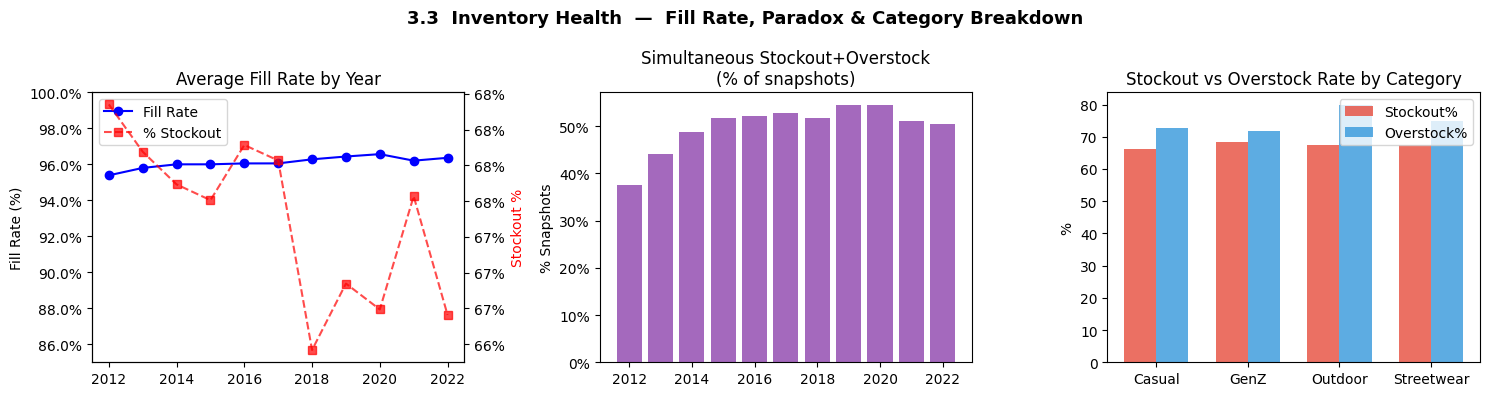

fig_eda09_33_inventory.png saved.


In [14]:

# ── 3.3e Inventory health chart ──────────────────────────────────────────────
inv_yr = inv.groupby('year').agg(
    avg_fill    = ('fill_rate','mean'),
    pct_stockout= ('stockout_flag','mean'),
    pct_over    = ('overstock_flag','mean'),
    pct_both    = ('stockout_flag', lambda x:
                   ((x==1) & (inv.loc[x.index,'overstock_flag']==1)).mean()),
).reset_index()
inv_yr['pct_stockout'] *= 100
inv_yr['pct_over']     *= 100
inv_yr['pct_both']     *= 100

cat_flags2 = inv.groupby('category').agg(
    pct_stockout= ('stockout_flag','mean'),
    pct_over    = ('overstock_flag','mean'),
    avg_fill    = ('fill_rate','mean'),
).reset_index()
cat_flags2['pct_stockout'] *= 100
cat_flags2['pct_over']     *= 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Fill rate trend
ax = axes[0]
ax.plot(inv_yr['year'], inv_yr['avg_fill']*100, 'b-o', label='Fill Rate')
ax.set_title('Average Fill Rate by Year')
ax.set_ylabel('Fill Rate (%)')
ax.set_ylim(85, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2 = ax.twinx()
ax2.plot(inv_yr['year'], inv_yr['pct_stockout'], 'r--s', alpha=0.7, label='% Stockout')
ax2.set_ylabel('Stockout %', color='red')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
lines1, _ = ax.get_legend_handles_labels()
lines2, _ = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, ['Fill Rate','% Stockout'], loc='upper left')

# (b) Paradox % by year
ax = axes[1]
ax.bar(inv_yr['year'], inv_yr['pct_both'], color='#8e44ad', alpha=0.8)
ax.set_title('Simultaneous Stockout+Overstock\n(% of snapshots)')
ax.set_ylabel('% Snapshots')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# (c) Stockout vs Overstock % by category
ax = axes[2]
x = range(len(cat_flags2))
w = 0.35
ax.bar([i-w/2 for i in x], cat_flags2['pct_stockout'], w, label='Stockout%', color='#e74c3c', alpha=0.8)
ax.bar([i+w/2 for i in x], cat_flags2['pct_over'],     w, label='Overstock%',color='#3498db', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(cat_flags2['category'])
ax.set_title('Stockout vs Overstock Rate by Category')
ax.set_ylabel('%')
ax.legend()

plt.suptitle('3.3  Inventory Health  —  Fill Rate, Paradox & Category Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda09_33_inventory.png', dpi=130, bbox_inches='tight')
plt.show()
print('fig_eda09_33_inventory.png saved.')
